In [1]:
import pandas as pd
import numpy as np
# from nltk.tokenize import word_tokenize
# from nltk.stem import WordNetLemmatizer
# import nltk

In [2]:
# Load the datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
val = pd.read_csv('val.csv')

# Split datasets into X and y
X_train = train['processed_post']
y_train = train['label']

X_test = test['processed_post']
y_test = test['label']

X_val = val['processed_post']
y_val = val['label']

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize text
tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()
X_val_tfidf = tfidf.transform(X_val).toarray()


Hypertuning 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Initialize the model
xgb_clf = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    seed=42
)

# Define the parameter distribution
param_dist = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 500],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1, 5]
}

# Perform the random search
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1,
    n_iter=30,  # Number of parameter combinations to try
    random_state=42
)

random_search.fit(X_train_tfidf, y_train)

# Best parameters and score
best_params = random_search.best_params_
best_score = random_search.best_score_
print("Best Parameters:", best_params)
print("Best Accuracy:", best_score)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


Training the model

In [25]:
import xgboost as xgb

# Convert data to DMatrix
dtrain = xgb.DMatrix(X_train_tfidf, label=y_train)
dtest = xgb.DMatrix(X_test_tfidf, label=y_test)
dval = xgb.DMatrix(X_val_tfidf, label=y_val)

# Train the model
params = {
    'objective': 'multi:softmax',  # Multi-class classification
    'num_class': 3,               # Number of classes (center, left, right)
    'max_depth': 6,
    'eta': 0.3,
    'eval_metric': 'mlogloss',
    'seed': 42
}

evals_result = {}

model = xgb.train(params, dtrain, num_boost_round=500, evals=[(dtest, 'test')], early_stopping_rounds=50, evals_result=evals_result)


[0]	test-mlogloss:1.09308
[1]	test-mlogloss:1.09021
[2]	test-mlogloss:1.08933
[3]	test-mlogloss:1.08803
[4]	test-mlogloss:1.08753
[5]	test-mlogloss:1.08636
[6]	test-mlogloss:1.08547
[7]	test-mlogloss:1.08440
[8]	test-mlogloss:1.08369
[9]	test-mlogloss:1.08500
[10]	test-mlogloss:1.08456
[11]	test-mlogloss:1.08474
[12]	test-mlogloss:1.08458
[13]	test-mlogloss:1.08384
[14]	test-mlogloss:1.08393
[15]	test-mlogloss:1.08508
[16]	test-mlogloss:1.08447
[17]	test-mlogloss:1.08502
[18]	test-mlogloss:1.08504
[19]	test-mlogloss:1.08579
[20]	test-mlogloss:1.08564
[21]	test-mlogloss:1.08569
[22]	test-mlogloss:1.08593
[23]	test-mlogloss:1.08696
[24]	test-mlogloss:1.08750
[25]	test-mlogloss:1.08759
[26]	test-mlogloss:1.08777
[27]	test-mlogloss:1.08867
[28]	test-mlogloss:1.08871
[29]	test-mlogloss:1.08871
[30]	test-mlogloss:1.09036
[31]	test-mlogloss:1.09094
[32]	test-mlogloss:1.09196
[33]	test-mlogloss:1.09172
[34]	test-mlogloss:1.09286
[35]	test-mlogloss:1.09363
[36]	test-mlogloss:1.09414
[37]	test-m

Evaluate accuracy on validation dataset

In [26]:
from sklearn.metrics import accuracy_score

# Predict on the validation set
y_val_pred = model.predict(dval)

# Convert predictions to integer type (as XGBoost predictions are floats)
y_val_pred = y_val_pred.astype(int)

# Compute accuracy
accuracy_val = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {accuracy_val * 100:.2f}%")

Validation Accuracy: 37.13%


Global feature importance

In [13]:
# Get feature importance using 'gain'
importance = model.get_score(importance_type='gain')

# Sort the features by importance score in descending order and get top 10
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10]

# Get the feature names from tf-idf
tfidf_feature_names = tfidf.get_feature_names_out()

# Print top 10 features with their importance scores
print("Top 10 Features by Importance:")
for feature_code, score in sorted_importance:
    # Extract the feature index from the code (e.g., f255 -> 255)
    feature_idx = int(feature_code[1:])  # Remove 'f' and convert to integer
    
    feature_name = tfidf_feature_names[feature_idx]

    # # Check if the feature code corresponds to a text feature or numeric feature
    # if feature_idx < len(tfidf_feature_names):  # Text feature
    #     feature_name = tfidf_feature_names[feature_idx]
    # else:  # Numeric feature (based on the position in the combined list)
    #     feature_name = numeric_feature_names[feature_idx - len(tfidf_feature_names)]

    print(f"{feature_name}: {score}")



Top 10 Features by Importance:
det: 32.42695617675781
government: 26.75497055053711
pilled: 22.91977882385254
en: 22.08233070373535
capitalism: 20.937171936035156
gun: 18.98933219909668
trans: 18.40642547607422
animals: 17.97234535217285
property: 17.920055389404297
workers: 16.130521774291992


## Finding biased words using SHAP scores

In [14]:
import shap

explainer = shap.TreeExplainer(model)
explanation = explainer(dtrain)

shap_values = explanation.values

C:\Users\arina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Plotting shap summary plots for each label

Shap summary plot for Label 0


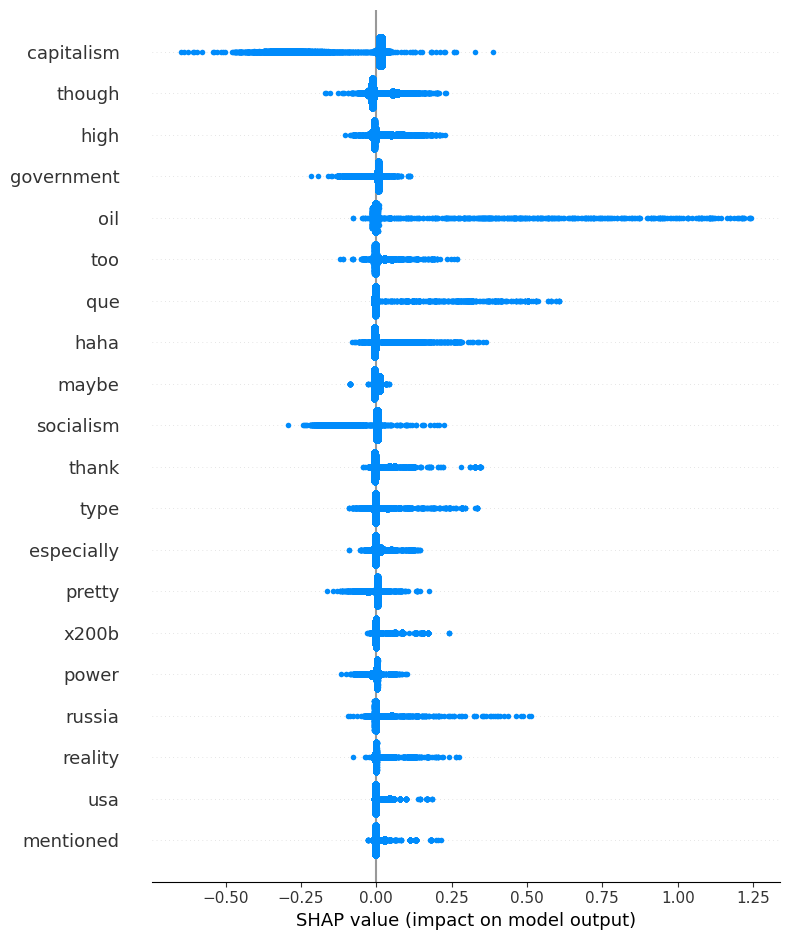

Shap summary plot for Label 1


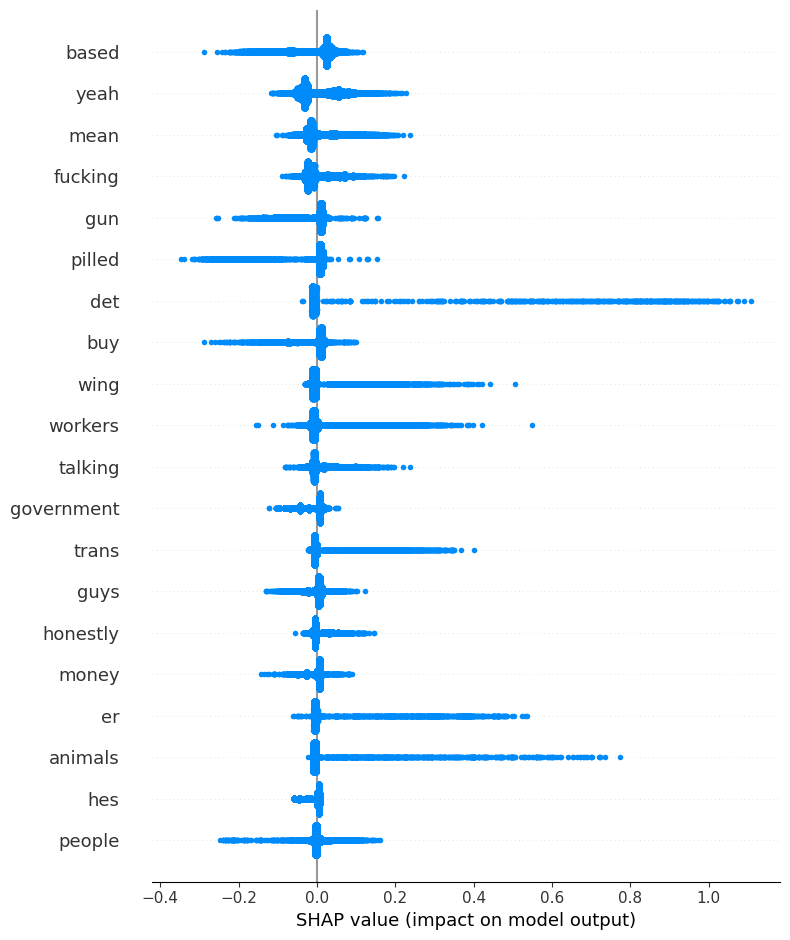

Shap summary plot for Label 2


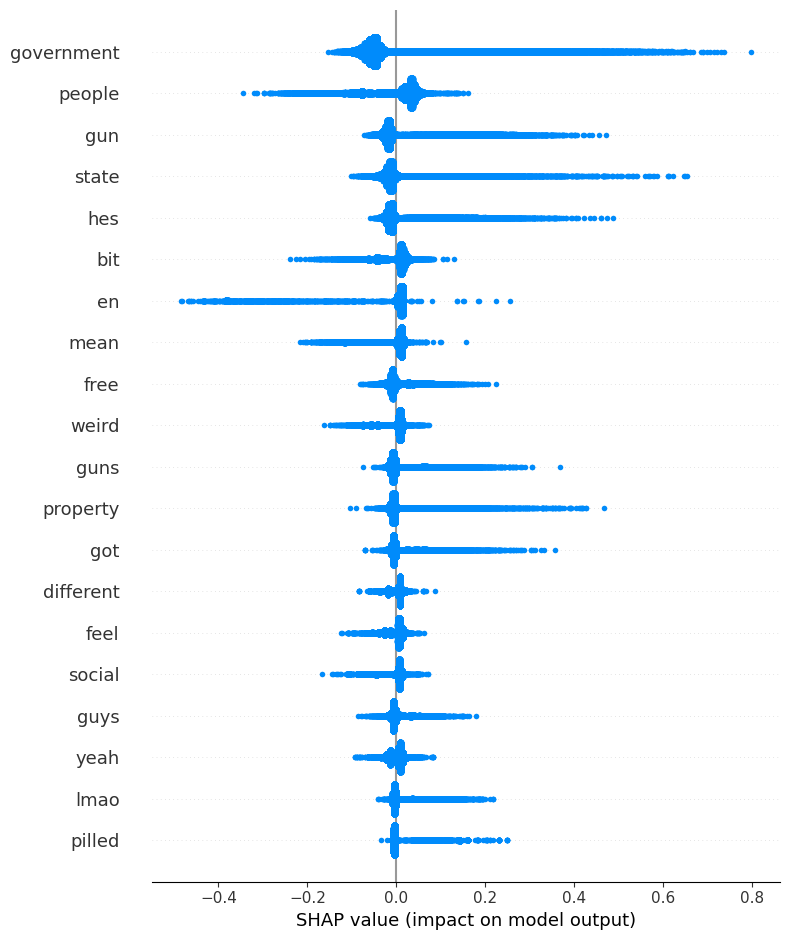

In [28]:
feature_names = list(tfidf_feature_names)
for label in [0,1,2]:
    print(f"Shap summary plot for Label {label}")
    shap.summary_plot(shap_values[:,:,label],feature_names=feature_names)

Aggregated SHAP summary plot for all 3 labels

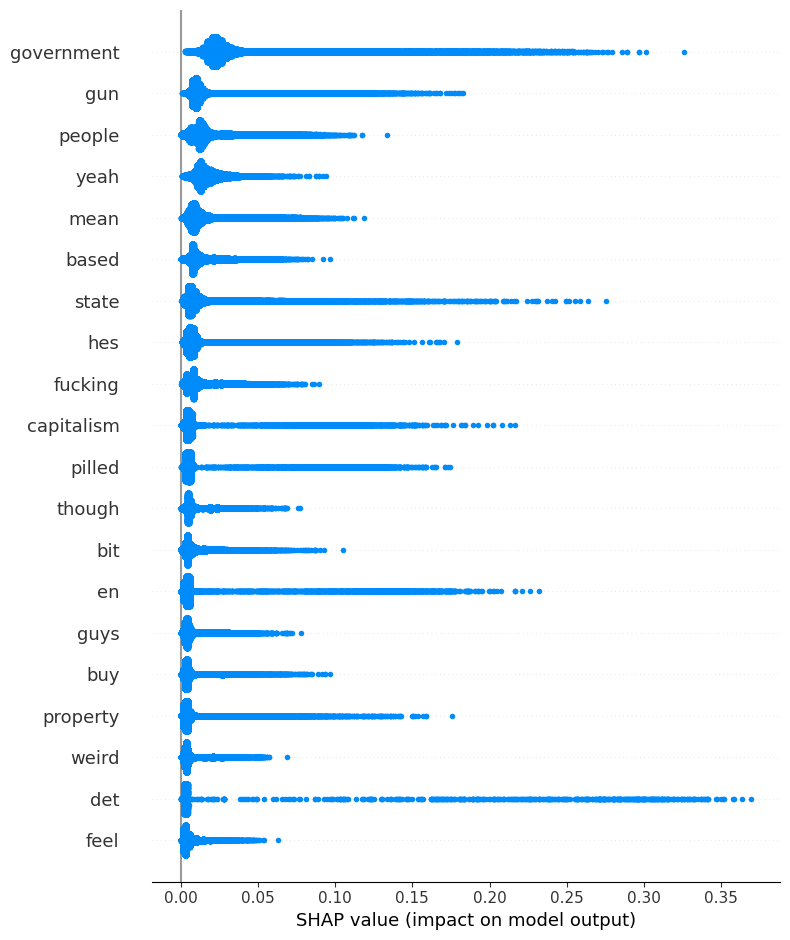

In [16]:
shap_values_aggregated = np.mean(np.abs(shap_values), axis=2)
shap.summary_plot(shap_values_aggregated, feature_names=feature_names)

Aggregate shap scores for each label

In [18]:
n_labels = shap_values.shape[2]

# Step 1: Aggregate SHAP values across samples for each feature and label
shap_aggregated = {}
for label_idx in range(n_labels):
    shap_aggregated[label_idx] = np.mean(np.abs(shap_values[:, :, label_idx]), axis=0)

Print biased words for each label

In [24]:
# Assuming shap_aggregated is a dictionary: {label_idx: array of n_features}
# and feature_names is a list of feature names

n_labels = len(shap_aggregated)  # Number of labels
n_features = len(feature_names)  # Number of features (words)

# Dictionaries to store biased words for each label
biased_words = {label: [] for label in range(n_labels)}
max_other_zero_words = {label: [] for label in range(n_labels)}

# Define a relative difference threshold (e.g., 20%)
relative_threshold = 1.0

for word_idx, word in enumerate(feature_names):
    # Get scores for the current word for all labels
    scores = {label: shap_aggregated[label][word_idx] for label in range(n_labels)}

    for label in scores:
        # Get scores for other labels
        other_labels = [l for l in scores if l != label]
        max_other_score = max([scores[l] for l in other_labels], default=0)

        # Separate words where max_other_score = 0
        if max_other_score == 0:
            if scores[label] > 0:
                max_other_zero_words[label].append((word, scores[label]))
            continue

        # Compute the relative difference
        relative_diff = (scores[label] - max_other_score) / max_other_score

        # Check if it exceeds the threshold
        if relative_diff > relative_threshold:
            biased_words[label].append((word, scores[label], max_other_score, relative_diff))

# Sort biased words for each label by relative difference in descending order
for label in biased_words:
    biased_words[label].sort(key=lambda x: x[3], reverse=True)  # Sort by relative_diff (4th element in tuple)

# Sort words with max_other_score = 0 by label score in descending order
for label in max_other_zero_words:
    max_other_zero_words[label].sort(key=lambda x: x[1], reverse=True)  # Sort by label_score (2nd element in tuple)

# Output biased words for each label
for label, words in biased_words.items():
    print(f"\nBiased words for label {label} (with non-zero max_other_score):")
    for word, label_score, max_other_score, relative_diff in words:
        print(f"  {word} - Label Score: {label_score:.6f}, Max Other Score: {max_other_score:.6f}, Relative Difference: {relative_diff:.2%}")

# Output words with max_other_score = 0 for each label
for label, words in max_other_zero_words.items():
    print(f"\nWords with max_other_score = 0 for label {label} (sorted by Label Score):")
    for word, label_score in words:
        print(f"  {word} - Label Score: {label_score:.6f}")



Biased words for label 0 (with non-zero max_other_score):
  maybe - Label Score: 0.007655, Max Other Score: 0.000027, Relative Difference: 27896.33%
  oil - Label Score: 0.009851, Max Other Score: 0.000058, Relative Difference: 16823.09%
  capitalism - Label Score: 0.028857, Max Other Score: 0.000339, Relative Difference: 8417.50%
  high - Label Score: 0.013799, Max Other Score: 0.000208, Relative Difference: 6534.45%
  power - Label Score: 0.004856, Max Other Score: 0.000075, Relative Difference: 6337.43%
  type - Label Score: 0.006648, Max Other Score: 0.000134, Relative Difference: 4852.33%
  though - Label Score: 0.024773, Max Other Score: 0.000557, Relative Difference: 4344.36%
  is - Label Score: 0.000582, Max Other Score: 0.000016, Relative Difference: 3618.30%
  road - Label Score: 0.002727, Max Other Score: 0.000091, Relative Difference: 2890.11%
  claim - Label Score: 0.000380, Max Other Score: 0.000014, Relative Difference: 2573.47%
  regardless - Label Score: 0.001346, Max